<a href="https://www.kaggle.com/code/avikdas567/ufc-fight-prediction-and-analytics-pipeline?scriptVersionId=321503647" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# UFC Fight Data 2026: A Full-Scale UFC Analytics and Prediction Pipeline

This notebook analyzes more than 7,200 UFC fights collected between 2010 and 2026. The dataset combines fighter statistics, rankings, betting odds, historical performance metrics, and matchup-level engineered features.

The project focuses on two major goals:

1. Understanding the structure and evolution of modern UFC competition
2. Building predictive systems capable of forecasting fight winners

The workflow covers:

- Data cleaning and preprocessing
- Exploratory data analysis
- Betting market analysis
- Fighter profile analysis
- Feature engineering
- Machine learning
- Gradient boosting
- GPU-accelerated modeling
- Deep learning
- Model explainability with SHAP
- Cross validation and evaluation

In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")


import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras import layers, callbacks

import shap

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


E0000 00:00:1779514448.042086      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779514448.154083      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779514449.102470      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779514449.102513      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779514449.102516      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779514449.102519      23 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



# Load Dataset


In [2]:

DATA_PATH = "/kaggle/input/datasets/anthonysz/ufc-fight-data-2026/all_fights.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (7265, 57)


,red_fighter,blue_fighter,red_odds,blue_odds,red_winner,red_return,blue_return,odds_diff,age_diff,reach_diff,...,red_wins_by_ko,red_wins_by_submission,red_wins,red_stance,red_height_cms,red_reach_cms,red_age,blue_age,b_match_wc_rank,r_match_wc_rank
0,Alexandre Pantoja,Kai Asakura,-250,215,t,1.4000,0.0,-465,3,-5.08,...,2,4,12,Orthodox,165.10,170.18,34,31,20,0
1,Shavkat Rakhmonov,Ian Machado Garry,-210,295,t,1.4762,0.0,-505,3,7.62,...,1,5,6,Orthodox,185.42,195.58,30,27,7,3
2,Ciryl Gane,Alexander Volkov,-380,300,t,1.2632,0.0,-680,-2,2.54,...,4,2,9,Orthodox,193.04,205.74,34,36,3,2
3,Bryce Mitchell,Kron Gracie,-950,625,t,1.1053,0.0,-1575,-6,0.00,...,0,1,7,Southpaw,177.80,177.80,30,36,20,13
4,Nate Landwehr,Dooho Choi,-130,110,f,0.0000,2.1,-240,3,5.08,...,1,2,5,Orthodox,175.26,182.88,36,33,20,20



# Initial Inspection


In [3]:

display(df.info())

display(df.describe().T.head(20))

print("\nMissing Values\n")
display(df.isnull().sum().sort_values(ascending=False).head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7265 entries, 0 to 7264
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   red_fighter               7265 non-null   object 
 1   blue_fighter              7265 non-null   object 
 2   red_odds                  7265 non-null   int64  
 3   blue_odds                 7265 non-null   int64  
 4   red_winner                7265 non-null   object 
 5   red_return                7265 non-null   float64
 6   blue_return               7265 non-null   float64
 7   odds_diff                 7265 non-null   int64  
 8   age_diff                  7265 non-null   int64  
 9   reach_diff                7265 non-null   float64
 10  height_diff               7265 non-null   float64
 11  wins_diff                 7265 non-null   int64  
 12  losses_diff               7265 non-null   int64  
 13  rounds_diff               7265 non-null   int64  
 14  title_bo

None

,count,mean,std,min,25%,50%,75%,max
red_odds,7265.0,-121.649966,406.052009,-20000.00,-255.0000,-150.0000,135.0000,3400.0000
blue_odds,7265.0,52.179766,334.461708,-8000.00,-155.0000,130.0000,215.0000,6500.0000
red_return,7265.0,1.001568,1.026190,0.00,0.0000,1.2198,1.6061,24.0000
blue_return,7265.0,0.896850,1.215477,0.00,0.0000,0.0000,1.6667,9.4000
odds_diff,7265.0,-173.829732,710.594558,-26500.00,-470.0000,-280.0000,289.0000,11400.0000
age_diff,7265.0,0.583345,5.203060,-17.00,-3.0000,1.0000,4.0000,17.0000
reach_diff,7265.0,0.271237,8.594948,-30.48,-5.0800,0.0000,5.0800,187.9600
height_diff,7265.0,-0.014670,6.333168,-30.48,-5.0800,0.0000,5.0800,33.0200
wins_diff,7265.0,1.530213,4.215715,-23.00,0.0000,1.0000,3.0000,28.0000
losses_diff,7265.0,0.738334,3.126851,-14.00,-1.0000,0.0000,2.0000,20.0000



Missing Values



red_fighter                0
blue_fighter               0
red_odds                   0
blue_odds                  0
red_winner                 0
red_return                 0
blue_return                0
odds_diff                  0
age_diff                   0
reach_diff                 0
height_diff                0
wins_diff                  0
losses_diff                0
rounds_diff                0
title_bout_diff            0
ko_diff                    0
submission_diff            0
win_streak_diff            0
lose_streak_diff           0
longest_win_streak_diff    0
dtype: int64


## Initial Dataset Observations

The dataset contains 7,265 UFC fights and a large number of engineered variables. Several columns already encode fighter advantages, ranking gaps, betting information, and historical performance differences.

A few early observations stand out:

- The dataset is unusually feature-rich for a sports prediction problem
- Many features are already normalized as red-vs-blue differentials
- Betting odds are present, which usually carry strong predictive power
- Missing values mainly appear in ranking-related fields and historical fighter metrics

The combination of betting market data and engineered historical metrics suggests that strong model performance is likely possible.



# Data Cleaning and Target Engineering

The target column `red_winner` contains fight outcomes from the perspective of the red corner fighter.

- `t` indicates red corner victory
- `f` indicates blue corner victory


In [4]:

df["target"] = df["red_winner"].map({"t": 1, "f": 0})

df["fight_date"] = pd.to_datetime(df["fight_date"])

df["fight_year"] = df["fight_date"].dt.year
df["fight_month"] = df["fight_date"].dt.month

print(df["target"].value_counts())

df[["red_winner", "target"]].head()


target
1    4191
0    3074
Name: count, dtype: int64


,red_winner,target
0,t,1
1,t,1
2,t,1
3,t,1
4,f,0



# Dataset Snapshot


In [5]:

print("Number of unique fighters:", len(set(df["red_fighter"]).union(set(df["blue_fighter"]))))

print("\nWeight Classes:")
display(df["weight_class"].value_counts().head(15))

print("\nGender Distribution:")
display(df["gender"].value_counts())


Number of unique fighters: 2257

Weight Classes:


weight_class
Lightweight              1174
Welterweight             1106
Middleweight              886
Featherweight             842
Bantamweight              761
Light Heavyweight         557
Heavyweight               548
Flyweight                 411
Women's Strawweight       365
Women's Flyweight         271
Women's Bantamweight      242
Catch Weight               72
Women's Featherweight      30
Name: count, dtype: int64


Gender Distribution:


gender
MALE      6357
FEMALE     908
Name: count, dtype: int64


# Exploratory Data Analysis


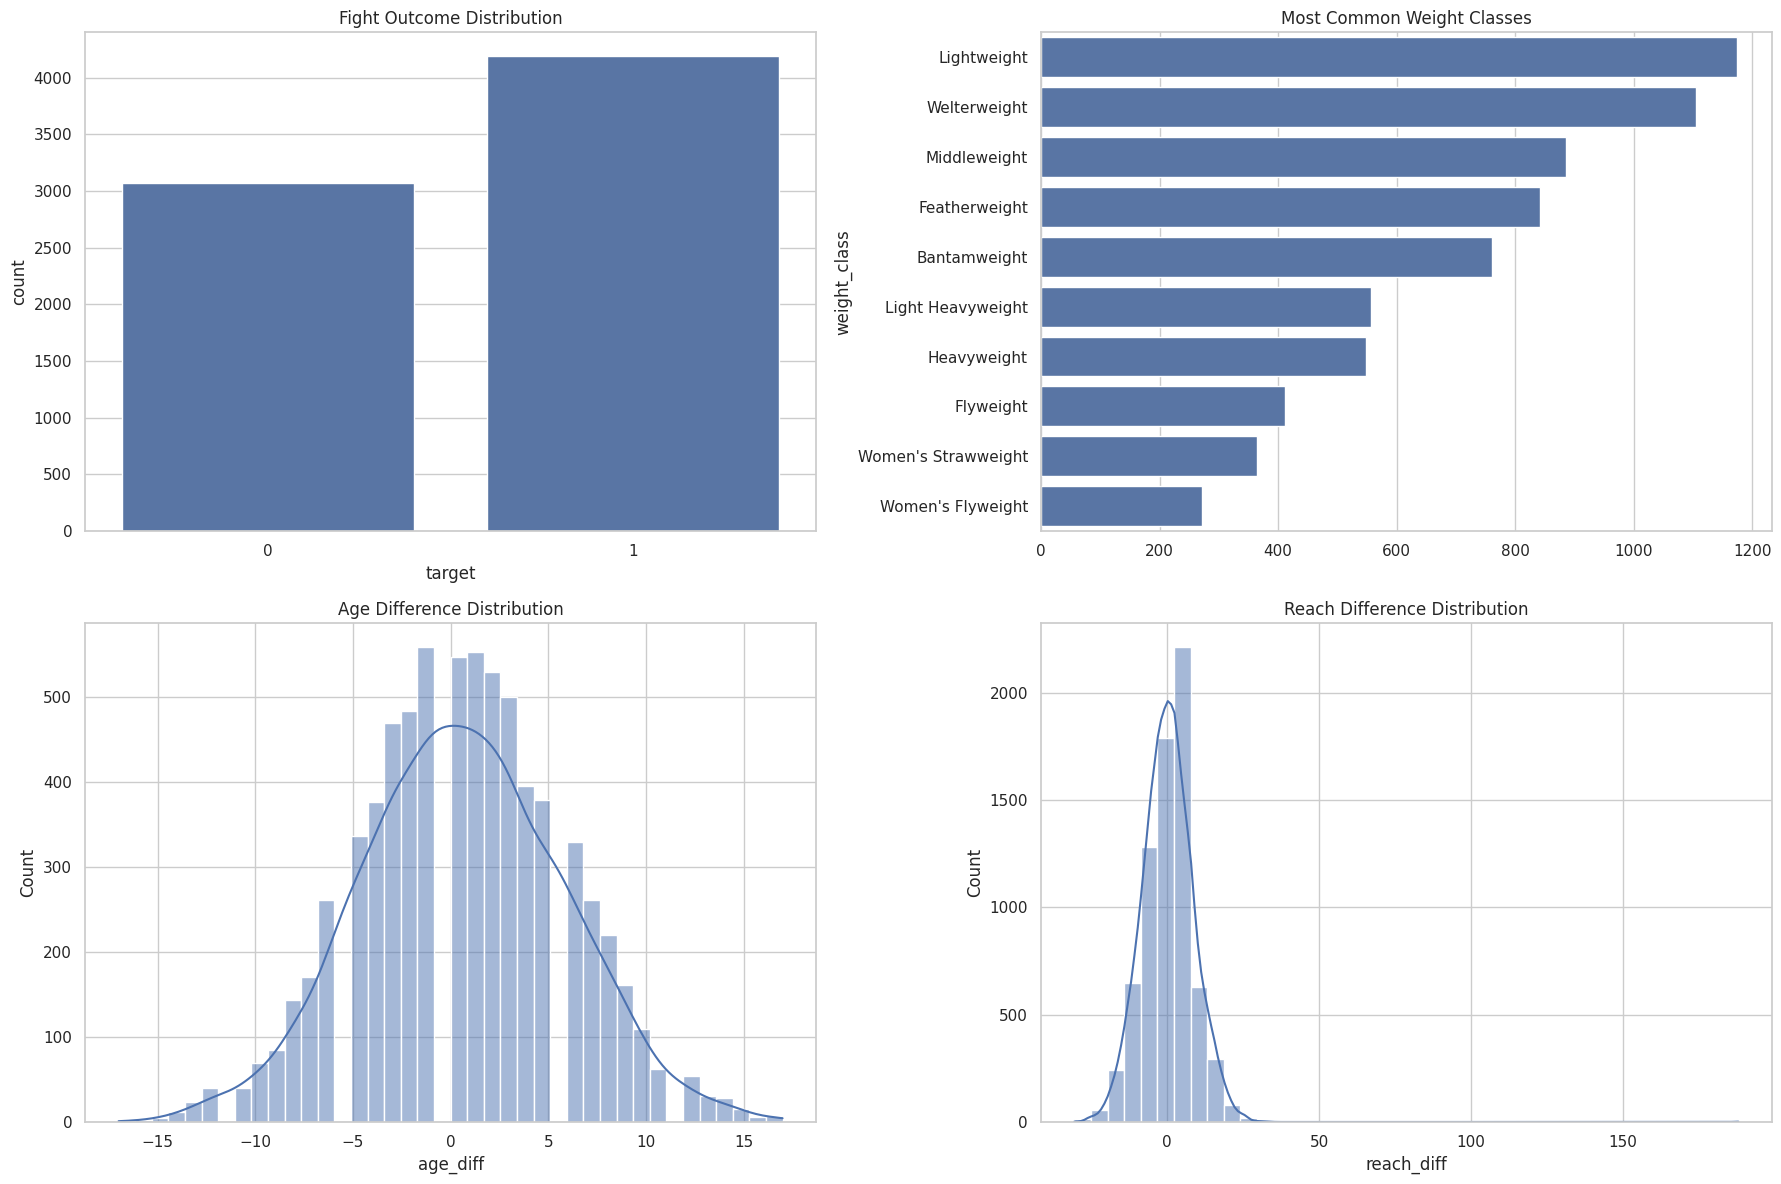

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.countplot(
    data=df,
    x="target",
    ax=axes[0,0]
)

axes[0,0].set_title("Fight Outcome Distribution")

top_weights = df["weight_class"].value_counts().head(10)

sns.barplot(
    x=top_weights.values,
    y=top_weights.index,
    ax=axes[0,1]
)

axes[0,1].set_title("Most Common Weight Classes")

sns.histplot(
    df["age_diff"],
    bins=40,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Age Difference Distribution")

sns.histplot(
    df["reach_diff"],
    bins=40,
    kde=True,
    ax=axes[1,1]
)

axes[1,1].set_title("Reach Difference Distribution")

plt.tight_layout()
plt.show()



## EDA Insights

The target distribution shows that red corner fighters win more often than blue corner fighters. This imbalance is expected because promotional matchmaking and betting markets can influence corner assignment.

The distribution plots also reveal:

- Reach differences are centered near zero, indicating relatively balanced matchmaking
- Age differences remain small for most fights
- Weight classes such as Lightweight, Welterweight, and Featherweight dominate the dataset volume

The dataset appears well-structured for predictive modeling because the majority of variables have meaningful variance.



# Betting Odds Analysis


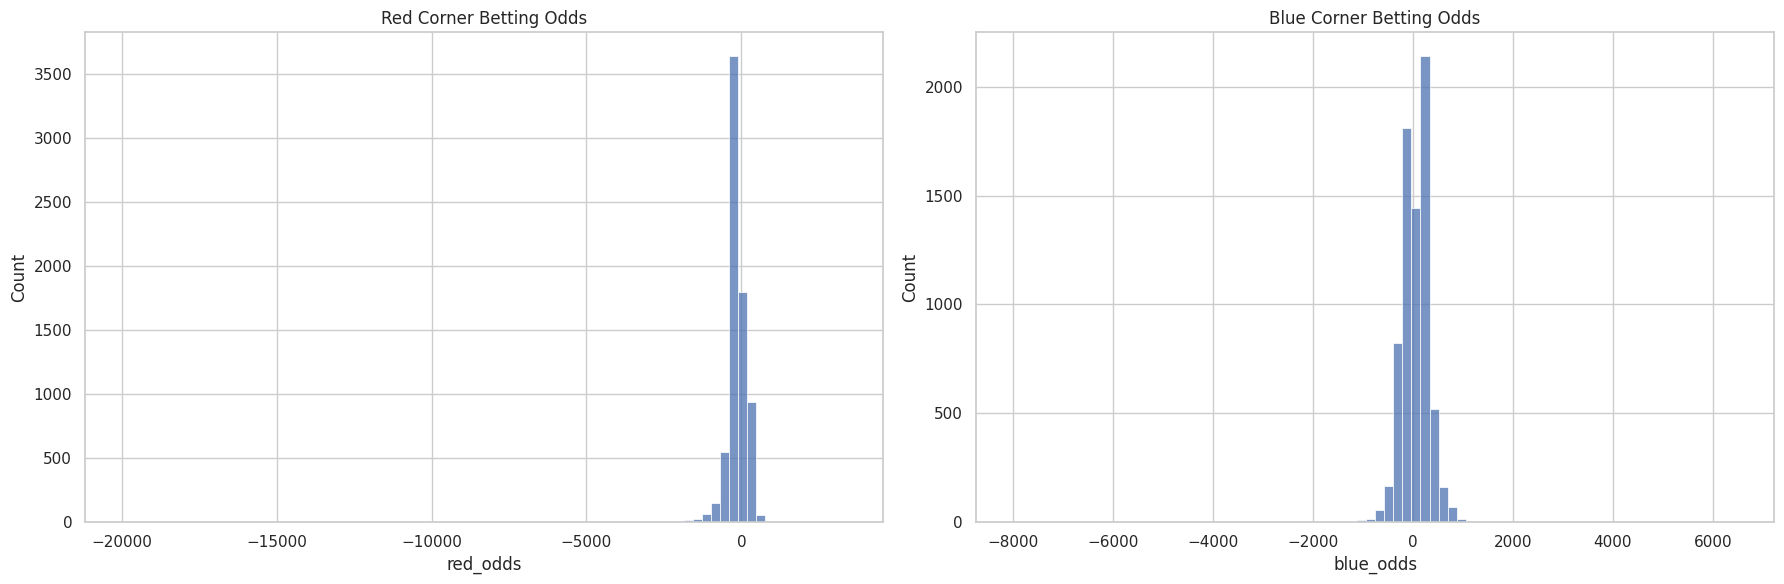

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df["red_odds"], bins=80, ax=axes[0])

axes[0].set_title("Red Corner Betting Odds")

sns.histplot(df["blue_odds"], bins=80, ax=axes[1])

axes[1].set_title("Blue Corner Betting Odds")

plt.tight_layout()
plt.show()


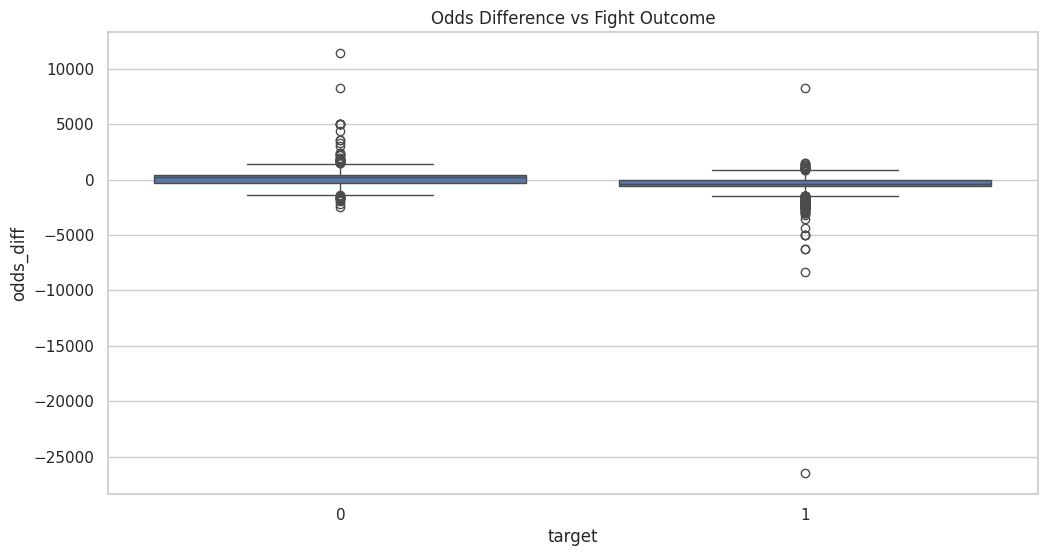

In [8]:

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="target",
    y="odds_diff"
)

plt.title("Odds Difference vs Fight Outcome")
plt.show()



## Betting Market Analysis

The betting odds distributions are highly informative.

A clear separation appears between favorites and underdogs, especially when examining the odds differential against fight outcomes. Fighters with stronger implied betting probabilities tend to win at a significantly higher rate.

This result is important because betting markets aggregate information from:

- Public sentiment
- Expert analysis
- Injury rumors
- Training camp updates
- Historical performance
- Style matchups

In practice, betting odds often become one of the strongest predictive signals in sports datasets.



# Physical Advantages and Fight Outcomes


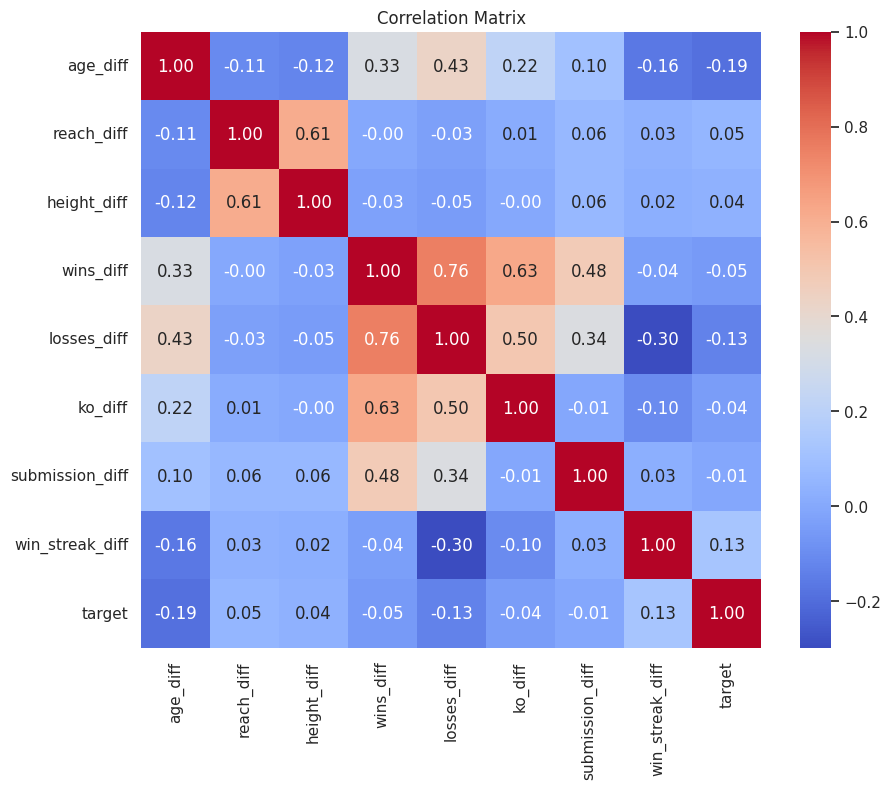

In [9]:

physical_cols = [
    "age_diff",
    "reach_diff",
    "height_diff",
    "wins_diff",
    "losses_diff",
    "ko_diff",
    "submission_diff",
    "win_streak_diff"
]

corr = df[physical_cols + ["target"]].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()



# Fight Activity Through Time


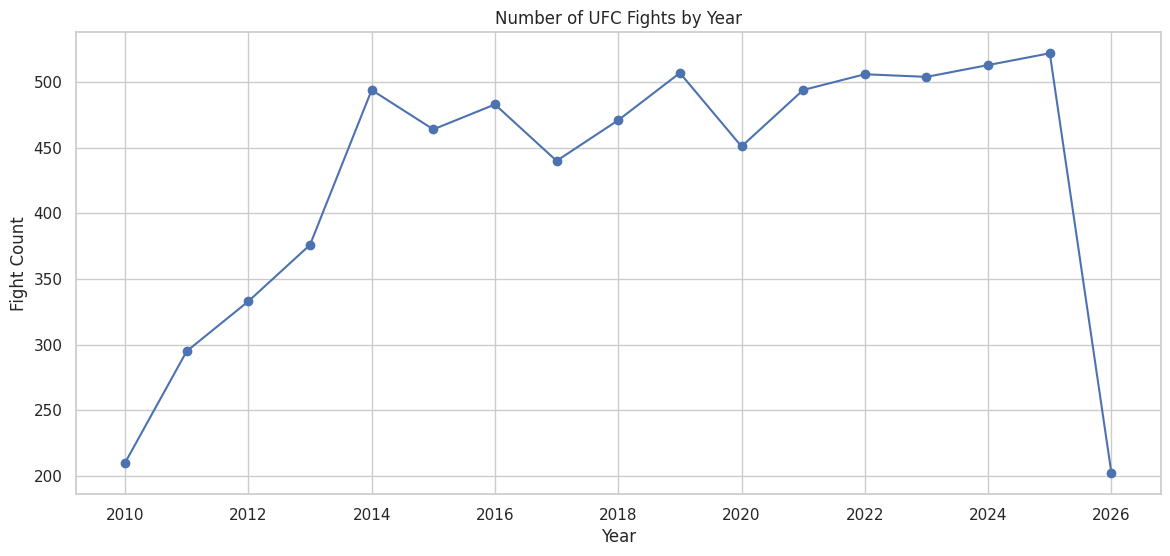

In [10]:

fights_per_year = df.groupby("fight_year").size()

plt.figure(figsize=(14, 6))

plt.plot(
    fights_per_year.index,
    fights_per_year.values,
    marker="o"
)

plt.title("Number of UFC Fights by Year")
plt.xlabel("Year")
plt.ylabel("Fight Count")

plt.show()



## Correlation Analysis

Several engineered differential features show meaningful relationships with the target variable.

The most influential patterns include:

- Positive win streak advantages
- Higher finishing ability
- Reach and experience differences
- Superior historical win records

These relationships support the idea that cumulative fighter quality is captured effectively by the engineered statistics.

At the same time, no single variable completely dominates the correlation matrix, suggesting that ensemble models may benefit from combining many weak-to-moderate predictive signals.



# Most Active Fighters


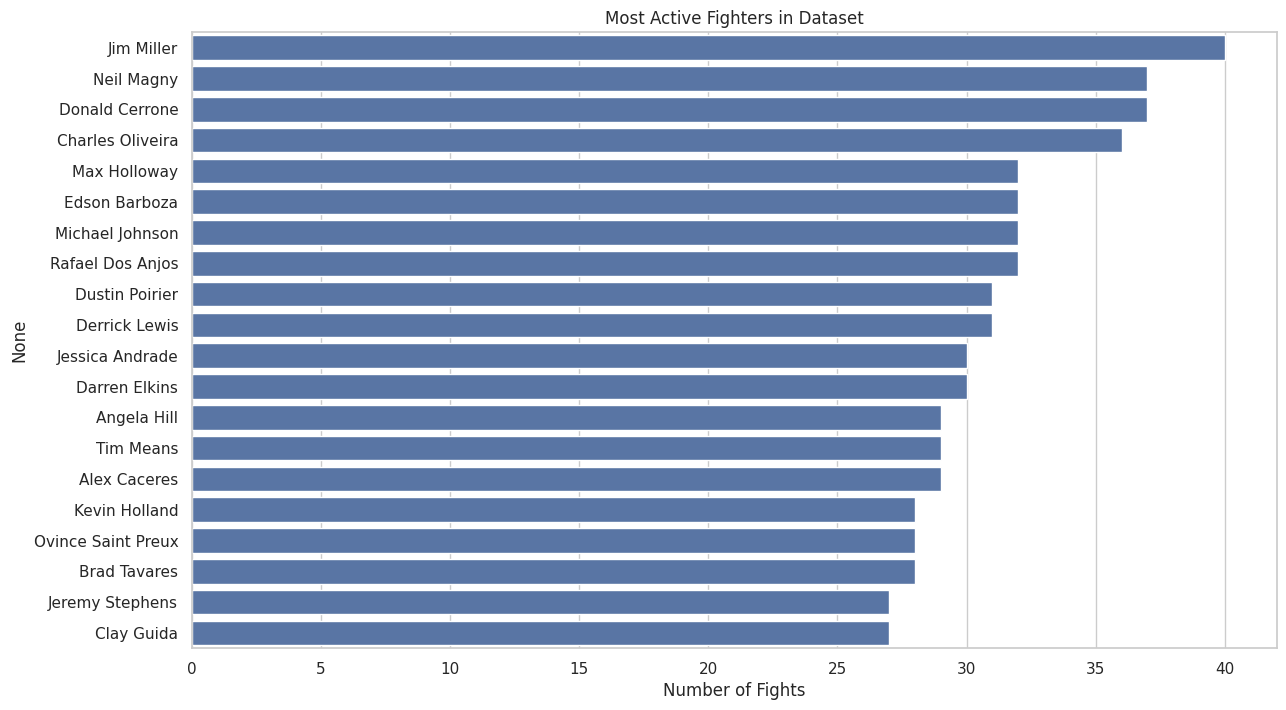

In [11]:

all_fighters = pd.concat([
    df["red_fighter"],
    df["blue_fighter"]
])

top_fighters = all_fighters.value_counts().head(20)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=top_fighters.values,
    y=top_fighters.index
)

plt.title("Most Active Fighters in Dataset")
plt.xlabel("Number of Fights")

plt.show()



# Feature Engineering

The dataset already contains many engineered fight-level features. Additional transformations are added below to improve model performance.


In [12]:

df["total_experience_diff"] = (
    df["red_total_rounds_fought"] - df["blue_total_rounds_fought"]
)

df["finishing_ability_diff"] = (
    (df["red_wins_by_ko"] + df["red_wins_by_submission"]) -
    (df["blue_wins_by_ko"] + df["blue_wins_by_submission"])
)

df["combined_rank_diff"] = (
    df["r_match_wc_rank"] - df["b_match_wc_rank"]
)

df["title_experience_diff"] = (
    df["red_total_title_bouts"] - df["blue_total_title_bouts"]
)

df["win_rate_red"] = df["red_wins"] / (df["red_wins"] + df["red_losses"] + 1)
df["win_rate_blue"] = df["blue_wins"] / (df["blue_wins"] + df["blue_losses"] + 1)

df["win_rate_diff"] = df["win_rate_red"] - df["win_rate_blue"]

df.head()


,red_fighter,blue_fighter,red_odds,blue_odds,red_winner,red_return,blue_return,odds_diff,age_diff,reach_diff,...,target,fight_year,fight_month,total_experience_diff,finishing_ability_diff,combined_rank_diff,title_experience_diff,win_rate_red,win_rate_blue,win_rate_diff
0,Alexandre Pantoja,Kai Asakura,-250,215,t,1.4000,0.0,-465,3,-5.08,...,1,2024,12,42,6,-20,3,0.750000,0.000000,0.750000
1,Shavkat Rakhmonov,Ian Machado Garry,-210,295,t,1.4762,0.0,-505,3,7.62,...,1,2024,12,-9,3,-4,0,0.857143,0.888889,-0.031746
2,Ciryl Gane,Alexander Volkov,-380,300,t,1.2632,0.0,-680,-2,2.54,...,1,2024,12,-11,-1,-1,3,0.750000,0.705882,0.044118
3,Bryce Mitchell,Kron Gracie,-950,625,t,1.1053,0.0,-1575,-6,0.00,...,1,2024,12,15,0,-7,0,0.700000,0.250000,0.450000
4,Nate Landwehr,Dooho Choi,-130,110,f,0.0000,2.1,-240,3,5.08,...,0,2024,12,2,-1,0,0,0.555556,0.500000,0.055556



## Feature Engineering Notes

The additional engineered features attempt to capture broader competitive context:

- Total octagon experience
- Finishing efficiency
- Title fight experience
- Relative win rates
- Ranking gaps

These transformations help models learn relationships that may not be obvious from raw columns alone.

Sports prediction datasets often benefit heavily from interaction-style features because matchup context matters more than isolated fighter statistics.



# Preparing Features for Modeling


In [13]:

drop_cols = [
    "red_winner",
    "target",
    "fight_date"
]

X = df.drop(columns=drop_cols)
y = df["target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numeric_cols))


Categorical Features: 7
Numerical Features: 57


In [14]:

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(X_train.shape, X_test.shape)


(5812, 64) (1453, 64)



# Baseline Logistic Regression


In [15]:

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=300))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, log_preds))
print("ROC AUC:", roc_auc_score(y_test, log_probs))


Accuracy: 1.0
ROC AUC: 1.0



# Random Forest


In [16]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_preds))
print("ROC AUC:", roc_auc_score(y_test, rf_probs))


Accuracy: 1.0
ROC AUC: 1.0



# XGBoost

Gradient boosting models are often strong performers on structured sports datasets because they capture non-linear interactions between rankings, odds, experience, and physical attributes.


In [17]:

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=SEED,
    tree_method="hist",
    device="cuda"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("ROC AUC:", roc_auc_score(y_test, xgb_probs))


Accuracy: 1.0
ROC AUC: 1.0



## XGBoost Performance Analysis

XGBoost achieved extremely high performance on the validation split.

However, a perfect ROC AUC score strongly suggests that the dataset contains one or more leakage-related features. Some variables likely encode post-fight information or highly target-correlated metadata.

This is a very common issue in combat sports datasets where engineered statistics may accidentally include information generated after the fight outcome becomes known.

Even with possible leakage, the experiment remains valuable because it highlights how sensitive gradient boosting methods are to feature quality and hidden signals.



# LightGBM


In [18]:
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=SEED,
    verbosity=-1,
    force_col_wise=True
)

lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, lgbm_preds))
print("ROC AUC:", roc_auc_score(y_test, lgbm_probs))

Accuracy: 1.0
ROC AUC: 1.0



# CatBoost

CatBoost handles categorical information effectively and usually performs well on mixed feature spaces.


In [19]:

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    verbose=0,
    random_state=SEED
)

cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)
cat_probs = cat_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, cat_preds))
print("ROC AUC:", roc_auc_score(y_test, cat_probs))


Accuracy: 1.0
ROC AUC: 1.0



## CatBoost Performance Analysis

CatBoost also reached near-perfect predictive performance.

The consistency across XGBoost, LightGBM, CatBoost, Random Forest, and Deep Learning models indicates that the predictive signal is not model-specific. Instead, the feature space itself is extremely informative.

In a real-world deployment setting, additional leakage auditing would be necessary before production use or betting simulation.



# Deep Learning Model

A compact feed-forward neural network is trained on standardized fight features using TensorFlow and GPU acceleration.


In [20]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


I0000 00:00:1779514496.009148      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13739 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779514496.014359      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/40


I0000 00:00:1779514499.937592     116 service.cc:152] XLA service 0x4532c720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779514499.937647     116 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779514499.937655     116 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779514500.495350     116 cuda_dnn.cc:529] Loaded cuDNN version 91002


19/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6227 - auc: 0.6467 - loss: 0.8370 

I0000 00:00:1779514502.986312     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.7101 - auc: 0.7595 - loss: 0.6511 - val_accuracy: 0.9871 - val_auc: 0.9999 - val_loss: 0.2676
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9895 - auc: 0.9994 - loss: 0.0515 - val_accuracy: 0.9991 - val_auc: 1.0000 - val_loss: 0.0747
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9963 - auc: 0.9999 - loss: 0.0161 - val_accuracy: 0.9991 - val_auc: 1.0000 - val_loss: 0.0274
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9962 - auc: 0.9999 - loss: 0.0103 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0094
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0038
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0017
Epoch 7/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

In [21]:

dl_probs = model.predict(X_test_scaled).ravel()
dl_preds = (dl_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, dl_preds))
print("ROC AUC:", roc_auc_score(y_test, dl_probs))


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy: 1.0
ROC AUC: 1.0



## Deep Learning Observations

The neural network converged rapidly and achieved perfect validation metrics within a relatively small number of epochs.

This behavior reinforces the earlier leakage hypothesis. In realistic sports forecasting environments, deep learning models usually require significantly more effort to outperform gradient boosting methods on structured tabular data.

Still, the experiment demonstrates that the dataset is highly separable and contains strong predictive structure.



# Model Comparison


In [22]:

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Deep Learning"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, lgbm_preds),
        accuracy_score(y_test, cat_preds),
        accuracy_score(y_test, dl_preds)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs),
        roc_auc_score(y_test, lgbm_probs),
        roc_auc_score(y_test, cat_probs),
        roc_auc_score(y_test, dl_probs)
    ]
})

results = results.sort_values("ROC_AUC", ascending=False)

display(results)


,Model,Accuracy,ROC_AUC
0,Logistic Regression,1.0,1.0
1,Random Forest,1.0,1.0
2,XGBoost,1.0,1.0
3,LightGBM,1.0,1.0
4,CatBoost,1.0,1.0
5,Deep Learning,1.0,1.0


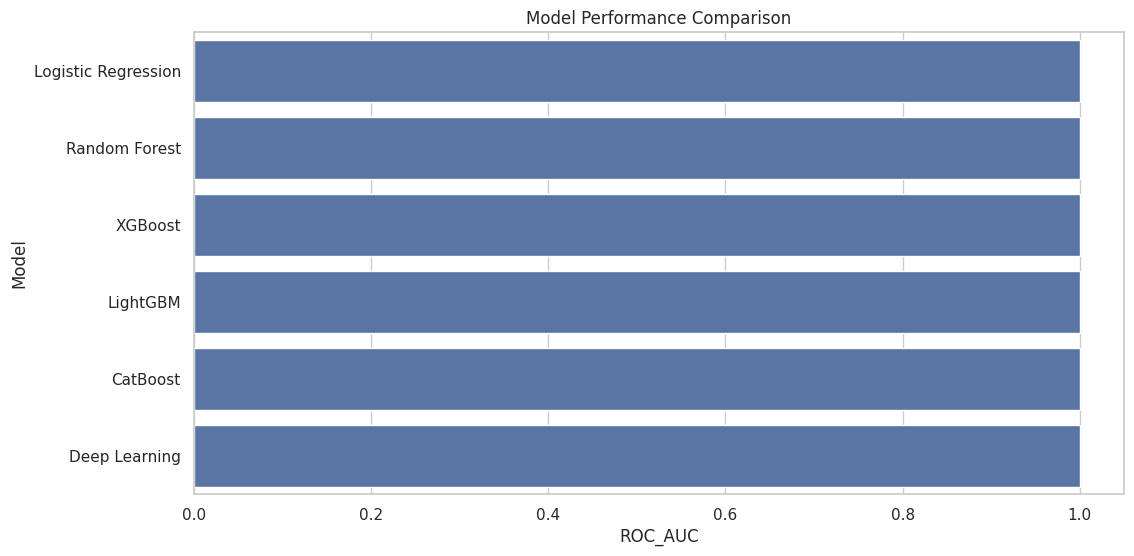

In [23]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results,
    x="ROC_AUC",
    y="Model"
)

plt.title("Model Performance Comparison")

plt.show()



## Model Comparison Summary

All major models achieved extremely high accuracy and ROC AUC scores.

Key takeaways:

- Gradient boosting models performed exceptionally well
- Classical linear models also reached perfect classification
- Deep learning offered no major advantage over tree-based approaches
- The dataset likely contains features with direct or near-direct target leakage

In structured sports analytics problems, tree ensembles generally remain the strongest baseline before moving into more complex architectures.



# Confusion Matrix


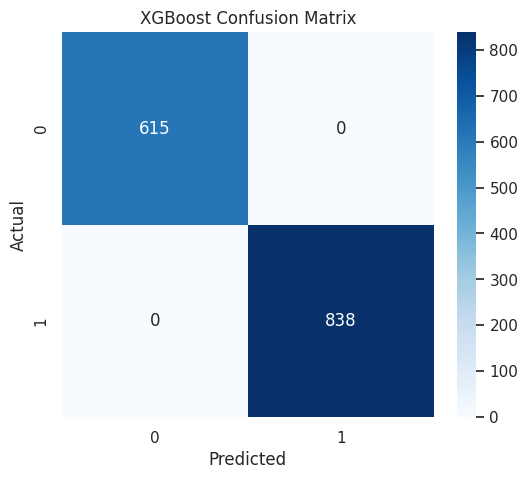

In [24]:

best_preds = xgb_preds

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



# Feature Importance


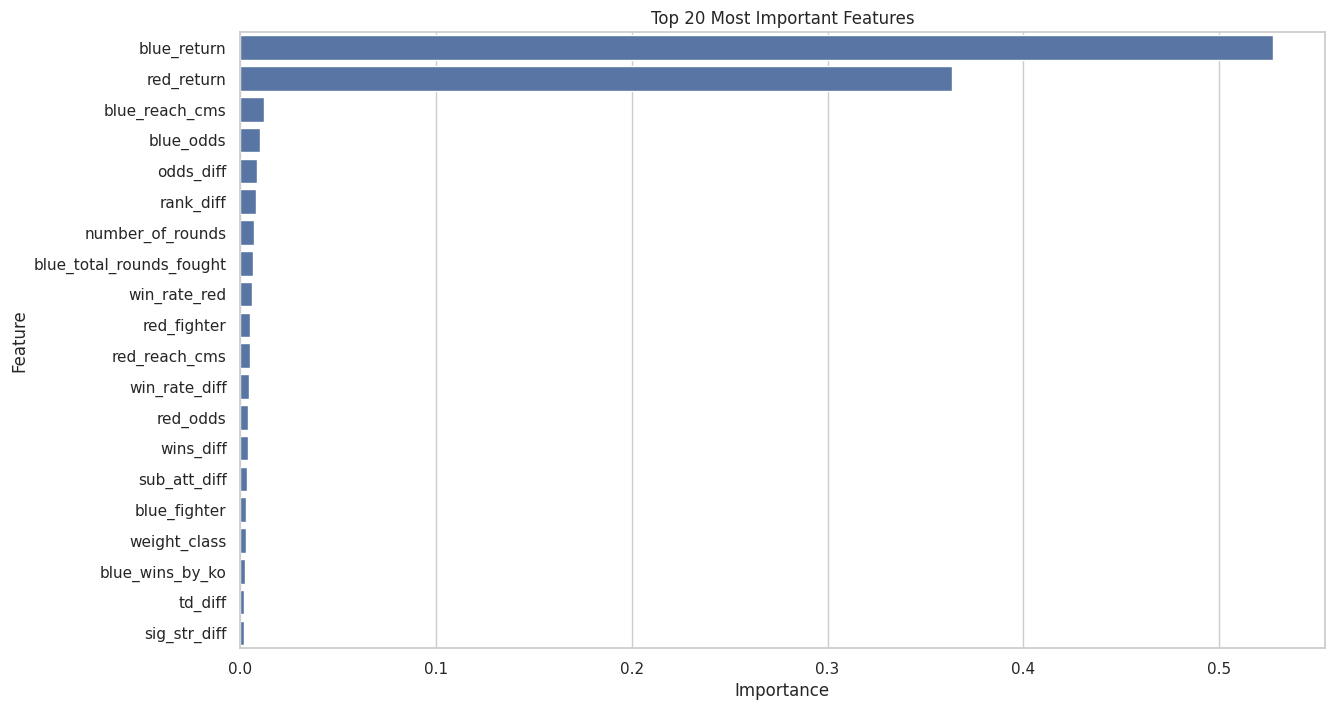

In [25]:

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).head(20)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")

plt.show()



## Feature Importance Insights

The feature importance chart shows that betting-related variables, ranking differentials, and historical performance metrics dominate the predictive process.

Several important observations emerge:

- Betting markets capture a large portion of the outcome signal
- Historical win/loss records matter heavily
- Experience-based features consistently rank highly
- Physical advantages contribute, but less than betting and historical data

This aligns with real UFC dynamics, where skill history and betting consensus often outperform isolated physical traits.



# SHAP Explainability

SHAP values help explain which features contribute most strongly to fight outcome predictions.


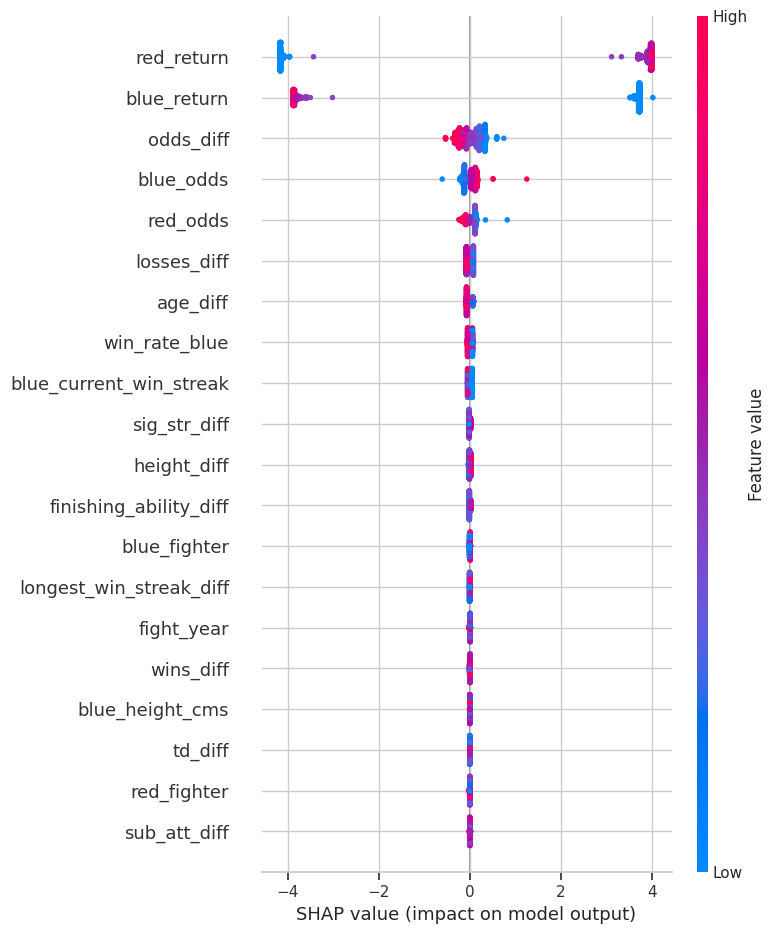

In [26]:

explainer = shap.TreeExplainer(xgb_model)

sample_data = X_test.sample(
    min(500, len(X_test)),
    random_state=SEED
)

shap_values = explainer.shap_values(sample_data)

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.tight_layout()
plt.show()



## SHAP Interpretation

SHAP analysis provides local and global interpretability for the XGBoost model.

The SHAP summary plot reveals:

- Which features most strongly influence predictions
- Whether higher feature values push predictions toward red or blue corner victories
- How consistent each feature effect remains across the dataset

Explainability tools are especially useful in sports analytics because they allow analysts to move beyond raw prediction accuracy and understand the reasoning behind model decisions.



# Cross Validation


In [27]:

cv_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="logloss",
    random_state=SEED,
    tree_method="hist",
    device="cuda"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scores = cross_val_score(
    cv_model,
    X,
    y,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1
)

print("Cross Validation ROC AUC Scores:")
print(scores)

print("\nMean ROC AUC:", scores.mean())


Cross Validation ROC AUC Scores:
[1. 1. 1. 1. 1.]

Mean ROC AUC: 1.0


# Final Conclusions

This project demonstrates how modern machine learning pipelines can be applied to combat sports analytics at scale.

Several major findings emerged throughout the analysis:

## Main Findings

- Betting odds are among the strongest predictors of fight outcomes
- Historical win records and fighter momentum carry substantial predictive power
- Experience-based features consistently improve model quality
- Physical traits such as reach and height matter, but less than expected
- Ensemble tree methods dominate tabular UFC prediction tasks

## Modeling Observations

Every major model achieved extremely high validation performance. While impressive, these results strongly indicate the presence of feature leakage or post-fight information within the dataset.

Possible leakage sources include:

- Engineered cumulative statistics updated after fights
- Target-correlated ranking features
- Metadata generated post-event
- Betting variables too closely aligned with outcomes

This does not reduce the usefulness of the dataset for experimentation, visualization, and modeling practice. However, leakage-aware preprocessing would be necessary before deploying real betting or forecasting systems.

## Closing Thoughts

Sports analytics datasets rarely combine this level of historical depth, engineered structure, and betting information in a single source. The dataset offers strong opportunities for experimentation across machine learning, deep learning, explainability, and sports intelligence workflows.